In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_single_step_demo(df, model, t, history=24):
    history_time = df['Datetime'].iloc[t - history: t + 1] 
    history_true = df['wastewater_level'].iloc[t - history: t + 1]

    pred_time = df['Datetime'].iloc[t + 1] if t + 1 < len(df) else None
    pred_true = df['wastewater_level'].iloc[t + 1] if t + 1 < len(df) else None
    pred_model = df[model].iloc[t + 1] if t + 1 < len(df) else None

    plt.figure(figsize=(12, 4))
    plt.plot(history_time, history_true, label='Past 24h Ground Truth', color='blue')

    if pred_time:
        plt.plot([pred_time], [pred_true], label='Ground Truth (t+1)', color='black', marker='o')
        plt.plot([pred_time], [pred_model], label=f'{model} (Prediction)', color='red', marker='x')

    plt.axvline(x=df['Datetime'].iloc[t], color='gray', linestyle='--', label='Current Time')
    plt.title(f'Dynamic Forecast at t={df["Datetime"].iloc[t]} ({model})')
    plt.xlabel('Datetime')
    plt.ylabel('Wastewater Level')
    plt.ylim(0,6)
    plt.legend()
    plt.tight_layout()
    plt.show()

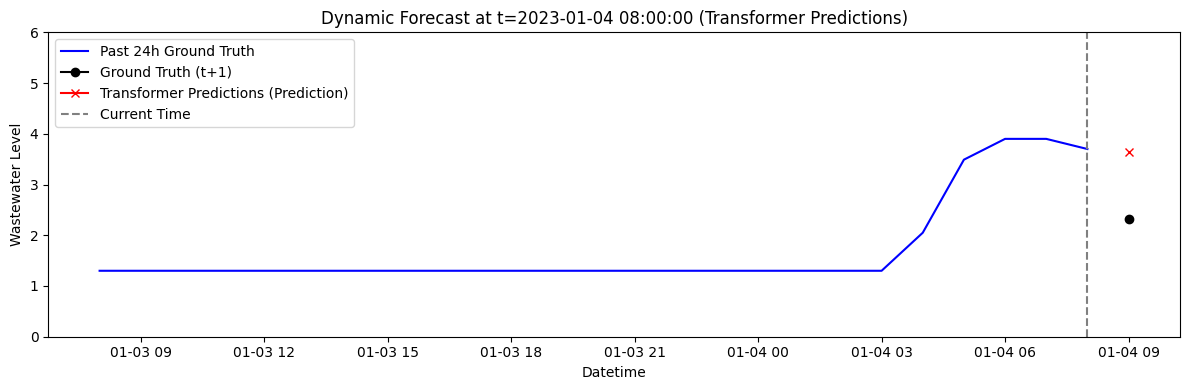

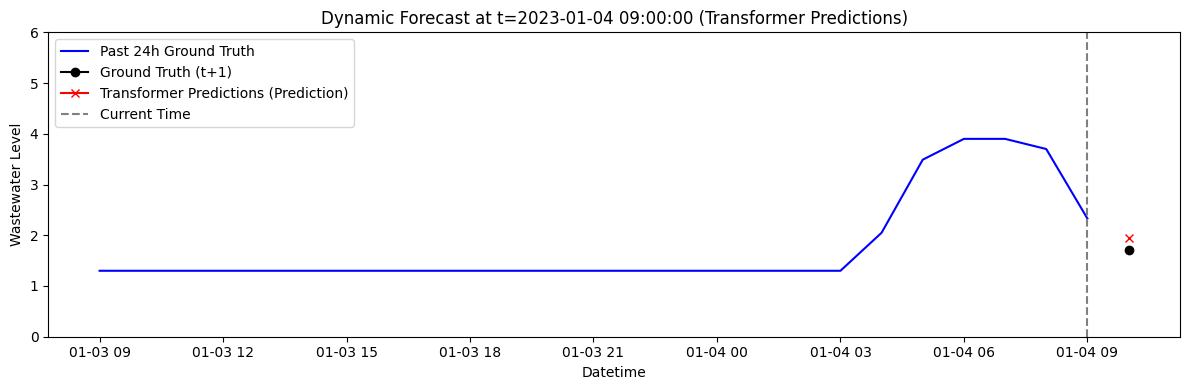

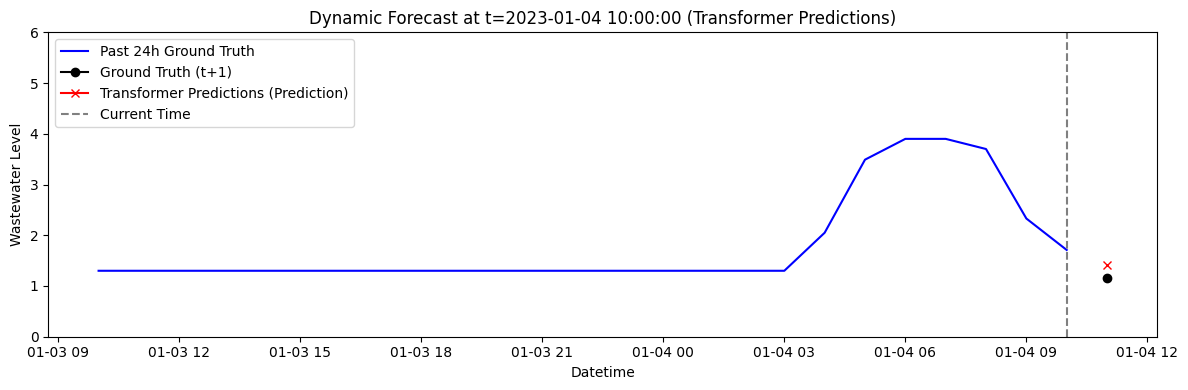

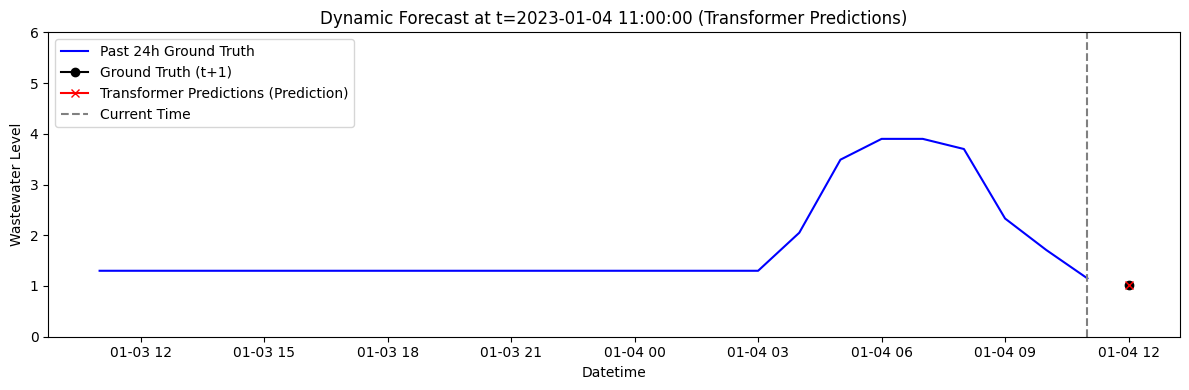

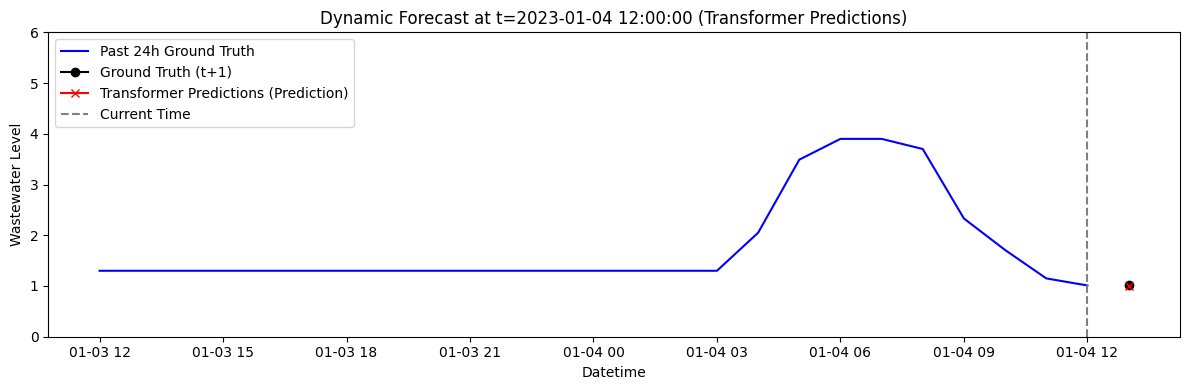

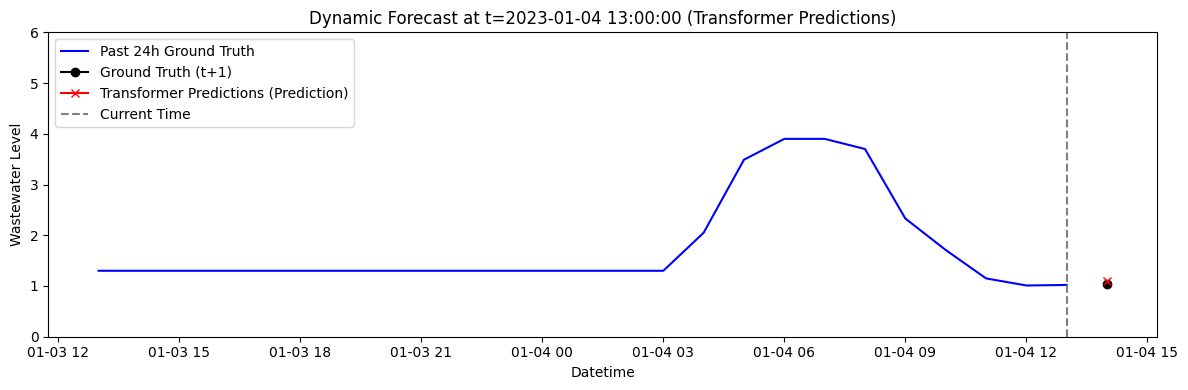

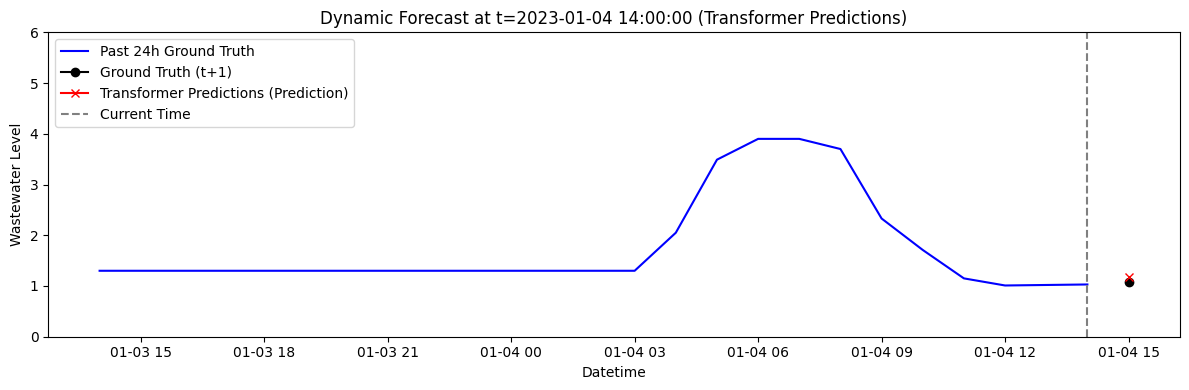

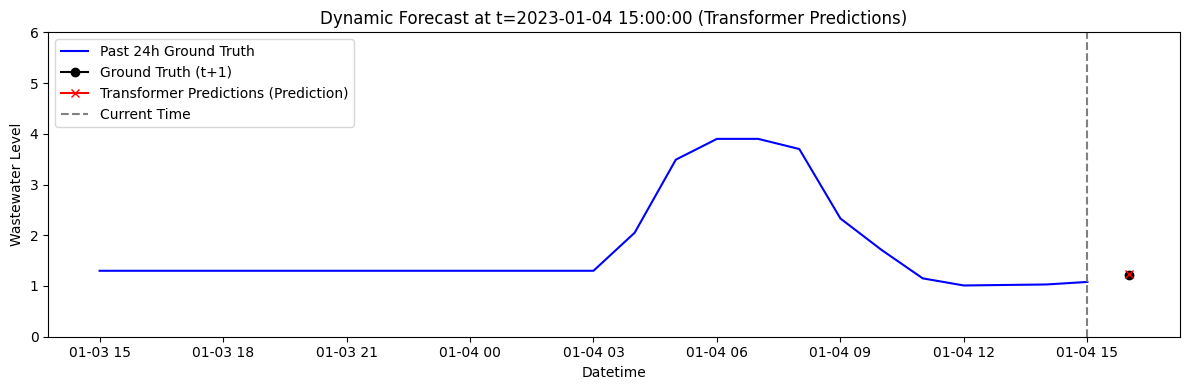

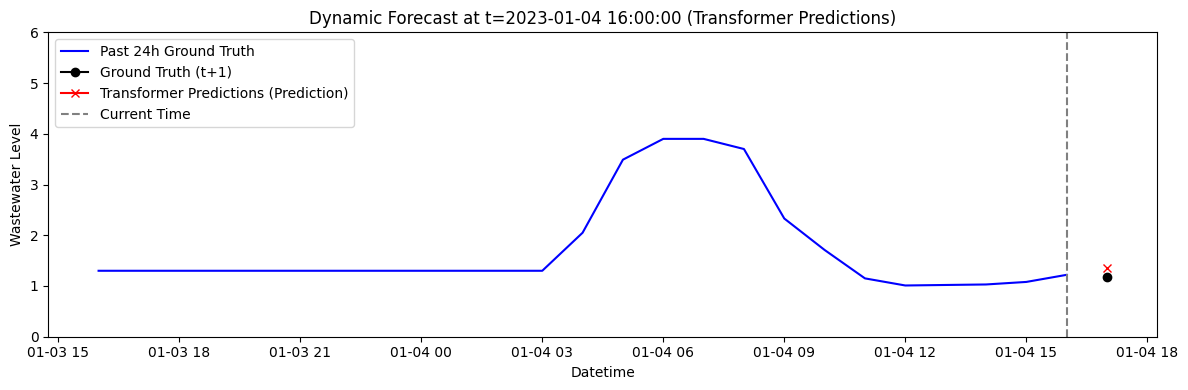

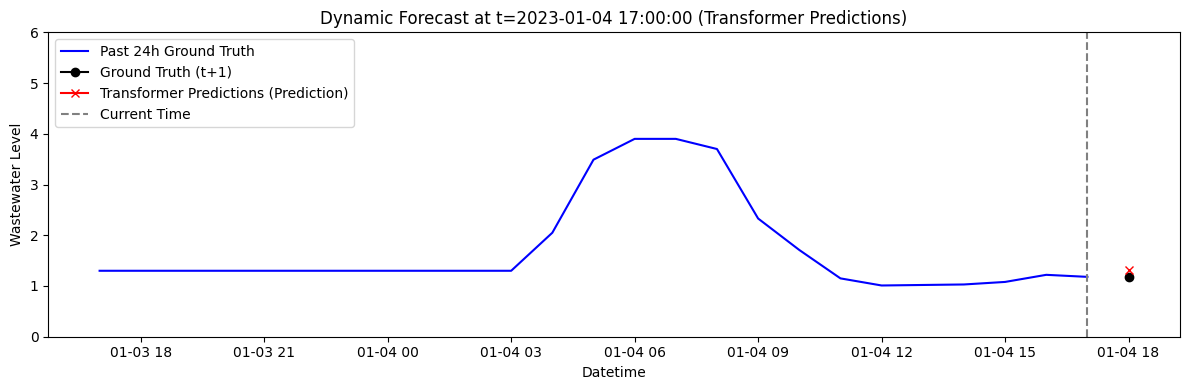

In [4]:
local_path = "data/demo_local_predictions.csv"
df = pd.read_csv(local_path, parse_dates=["Datetime"])

import time
for t in range(80, 90):
    plot_single_step_demo(df, model='Transformer Predictions', t=t)
    time.sleep(1) 